# FINAL PROJECT

**Deliverables**:
  1. Your version of this notebook, where you create the required agents (complete all the associated tasks)

  2. After training your agents, you might want to save those learnt values. This can be a dictionary with the `optimal policy`, or `Q-values`. If an approximate method was used, you can provide the `final weights`, etc.

  3. A short report (no more than 10 pages), where you explain your methodology, chosen parameters, visualisations of the learning process (how rewards increase over time, or how loss functions decrease).

  4. Upload to `Faser` a .zip file of all the deliverables (including th optimal Q-values/weights/policies)

**Evaluation**: Your projects will be evaluated primarily on the development of the agents, not necessarily in their performance. Being said that, better performance will lead in general to better marks.

## 0. Setup

In [1]:
import os

import numpy as np
import gymnasium as gym
from IPython.display import Image, display
import imageio

from collections import defaultdict
from tqdm import tqdm

from src.logger import LogManager
from src.utils import save_policy, plot_learning_curve
from src.optimization import param_opt_pipeline

In [2]:
manager = LogManager()

main_log = manager.get_logger("Main", "main.log")

In [3]:
env = gym.make("Acrobot-v1", render_mode = "rgb_array")
state = env.reset()
new_step_api = True

main_log.info("--- New Session Started ---")
main_log.info(f"Environment: Acrobot-v1")
main_log.info(f"Initial State: {state}")
main_log.info(f"State Space: {env.observation_space}")
main_log.info(f"Action Space: {env.action_space}")

2026-04-10 21:32:31 | INFO    | --- New Session Started ---
2026-04-10 21:32:31 | INFO    | Environment: Acrobot-v1
2026-04-10 21:32:31 | INFO    | Initial State: (array([ 1.0000000e+00,  2.2511506e-04,  9.9940580e-01,  3.4468617e-02,
       -8.8798545e-02, -1.7397854e-02], dtype=float32), {})
2026-04-10 21:32:31 | INFO    | State Space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
2026-04-10 21:32:31 | INFO    | Action Space: Discrete(3)


[ACROBOT ENVIRONMENT](https://gymnasium.farama.org/environments/classic_control/acrobot/)

Below is the default discretisation (for the states. Actions are already discrete). If you consider that a different one, could lead to better performance, feel free to modify it, and indicate this in your report.

In [4]:
# --- CONSTANTS ---
TRIG_BINS = 5  # First 4 dimensions: COS, SIN; COS, SIN
ANGLE_BINS = 8   # Last 2 dimensions: Angular velocities
BINS = np.array([TRIG_BINS]*4 + [ANGLE_BINS]*2)

UPPER_BOUNDS = np.array([1, 1, 1, 1, 4 * np.pi, 9 * np.pi])
LOWER_BOUNDS = np.array([-1, -1, -1, -1, -4 * np.pi, -9 * np.pi])

def discretise(obs):
    """
    Optimized discretisation using NumPy vectorization.
    """
    # Vectorized calculation: (obs - low) / (high - low)
    ratios = (obs - LOWER_BOUNDS) / (UPPER_BOUNDS - LOWER_BOUNDS)
    
    # Scale to bins and clip to stay within array bounds
    new_obs = np.round((BINS - 1) * ratios).astype(int)
    new_obs = np.clip(new_obs, 0, BINS - 1)
    
    return tuple(new_obs)

In [5]:
main_log.info(f"Discretization Bins: {BINS}")

2026-04-10 21:32:31 | INFO    | Discretization Bins: [5 5 5 5 8 8]


**Default parameters**: I defined the following parameters as the default ones, they will allow you to run things in a reasonable time for testing. However, for properly training your agents, you will need longer time.

**Remark:** the visualisation is just a guidance of performance, the real test of performance is the cumulative rewards.

In [6]:
# --- HYPERPARAMETERS ---
DEFAULT_PARAMS = {
    "alpha": 0.15,
    "gamma": 0.99,
    "epsilon": 1.0,
    "epsilon_decay": 0.999,
    "epsilon_min": 0.05,
    "n_episodes": 500
}

**Useful tools**:

You will need to train your algorithms with different sets of parameters. To avoid losing good performing ones, I recommend to use tools such as [Pickle](https://docs.python.org/3/library/pickle.html): This allows to save dictionaries/arrays in a compressed format (using the function `dump`), and then you can load them back, to test the performance (using function `load`)

How to use it? if your trained `Q` value dictionary is called `Q_trained`. You can define the following functions to save/load them.

In [7]:
# error running action = np.argmax(Q[state])
# fixed by changing np.argmax(Q[state]) -> np.argmax(Q[disc_state])

def tester(Q, filename='record.gif', max_steps = 500):
    env = gym.make("Acrobot-v1", render_mode="rgb_array")

    frames = []
    state, _ = env.reset()
    disc_state = tuple(discretise(state))
    action = np.argmax(Q[disc_state])

    for k in tqdm(range(max_steps)):
        frames.append(env.render())

        next_state, reward, done, truncated, _ = env.step(action)
        disc_next_state = tuple(discretise(next_state))  # discretise the next state

        if done or truncated:
            frames.append(env.render())
            break

        action = np.argmax(Q[disc_next_state]) # get the next discrete action, and repeat.
    path = os.path.join("results/", filename)
    imageio.mimsave(path, frames, fps=50)
    return path

In [8]:
def run_experiment(algorithm_func, name, params = DEFAULT_PARAMS):
    """
    Wraps training, plotting, and recording into one call.
    """
    main_log.info(f"Starting Experiment: {name}")
    main_log.info(f"Hyperparameters: {params}")
    
    # 1. Train
    Q_table, rewards = algorithm_func(env, params=params)

    avg_reward = np.mean(rewards[-100:])
    main_log.info(f"Experiment {name} Finished. Final Avg Reward (last 100 eps): {avg_reward:.2f}")
    
    # 2. Save
    save_policy(Q_table, name)
    
    # 3. Visualize
    plot_learning_curve(rewards, name)

    gif_path = tester(Q_table, filename=f"{name.lower()}.gif")
    display(Image(filename=gif_path))
    
    return Q_table, rewards

In [9]:
def get_epsilon_greedy_action(q_table, state, n_actions, epsilon, rng):
    """Centralized action selection logic."""
    if rng.random() < epsilon:
        return rng.integers(n_actions)
    return np.argmax(q_table[state])

## 1. Baseline

**SARSA implementation**: I give you the SARSA implementation for guidance. This should help you to create the algorithms needed for Tasks 1 to 5.

In [10]:
def train_sarsa(env, params = DEFAULT_PARAMS, seed = 42):
    """
    SARSA implementation using a centralized parameter dictionary.
    """

    rng = np.random.default_rng(seed)
    
    alpha, gamma = params["alpha"], params["gamma"]
    epsilon, epsilon_decay = params["epsilon"], params["epsilon_decay"]
    n_actions = env.action_space.n
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards_history = []

    for ep in tqdm(range(params["n_episodes"]), desc="Training SARSA"):
        obs, _ = env.reset()
        state = discretise(obs)
        action = get_epsilon_greedy_action(Q, state, n_actions, epsilon, rng)

        total_reward = 0
        done = False

        while not done:
            next_obs, reward, term, trunc, _ = env.step(action)
            next_state = discretise(next_obs)
            
            next_action = get_epsilon_greedy_action(Q, next_state, n_actions, epsilon, rng)

            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

            state, action = next_state, next_action
            total_reward += reward
            done = term or trunc

        epsilon = max(params["epsilon_min"], epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

2026-04-10 21:32:31 | INFO    | Starting Experiment: SARSA
2026-04-10 21:32:31 | INFO    | Hyperparameters: {'alpha': 0.15, 'gamma': 0.99, 'epsilon': 1.0, 'epsilon_decay': 0.999, 'epsilon_min': 0.05, 'n_episodes': 500}


Training SARSA: 100%|██████████| 500/500 [01:05<00:00,  7.62it/s]

2026-04-10 21:33:36 | INFO    | Experiment SARSA Finished. Final Avg Reward (last 100 eps): -473.16
2026-04-10 21:33:37 | INFO    | Model checkpoint saved: models/SARSA.pkl


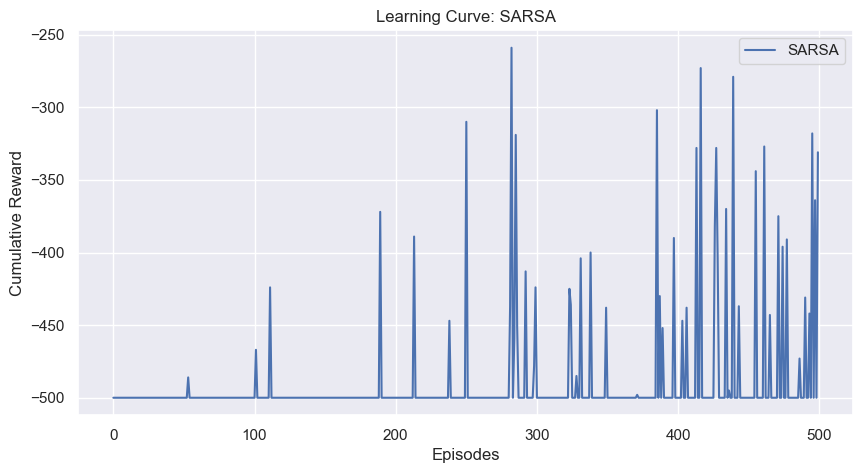

2026-04-10 21:33:37 | INFO    | Plot created in notebook.


  0%|          | 0/500 [00:00<?, ?it/s]<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
c:\Users\rcorr\anaconda3\envs\reinforced\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
 84%|████████▍ | 421/500 [00:03<00:00, 114.26it/s]


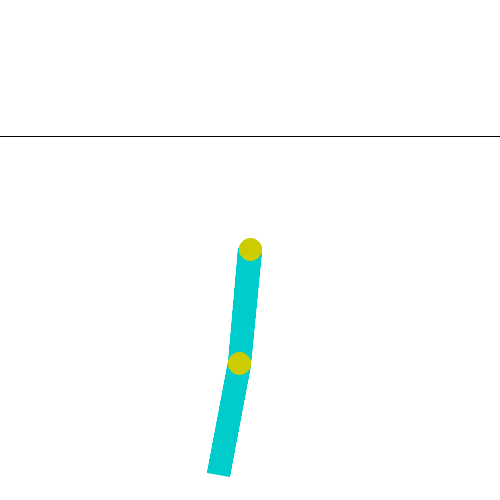

In [11]:
Q_0, rewards_0 = run_experiment(train_sarsa, "SARSA")

## 2. Q-Learning Experiments [UG: 30 /  PGT: 20] marks


In here you will need to implement a version of Q-Learning, test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of Q-learning
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [12]:
def get_iqm(sample):
    sample = np.array(sample)
    q1 = np.quantile(sample, 0.25)
    q3 = np.quantile(sample, 0.75)
    return np.mean(sample[(sample >= q1) & (sample <= q3)])

In [13]:
def train_Q(env, params = DEFAULT_PARAMS, show_progress = False, seed = 42):
    """
    Q-Learning implementation using a centralized parameter dictionary.
    """

    rng = np.random.default_rng(seed)
    
    alpha, gamma = params["alpha"], params["gamma"]
    epsilon, epsilon_decay = params["epsilon"], params["epsilon_decay"]
    n_actions = env.action_space.n
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards_history = []

    # Use a conditional tqdm
    iterator = range(params["n_episodes"])
    if show_progress:
        iterator = tqdm(iterator, desc="Training Q-Learning", leave=False)

    for ep in iterator:
        obs, _ = env.reset()
        state = discretise(obs)

        total_reward = 0
        done = False

        while not done:
            action = get_epsilon_greedy_action(Q, state, n_actions, epsilon, rng)

            next_obs, reward, term, trunc, _ = env.step(action)
            next_state = discretise(next_obs)

            # Off policy
        
            Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])

            state = next_state
            total_reward += reward
            done = term or trunc

        epsilon = max(params["epsilon_min"], epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

2026-04-10 21:34:02 | INFO    | Starting Experiment: Q-learning
2026-04-10 21:34:02 | INFO    | Hyperparameters: {'alpha': 0.15, 'gamma': 0.99, 'epsilon': 1.0, 'epsilon_decay': 0.999, 'epsilon_min': 0.05, 'n_episodes': 500}
2026-04-10 21:35:13 | INFO    | Experiment Q-learning Finished. Final Avg Reward (last 100 eps): -478.50
2026-04-10 21:35:13 | INFO    | Model checkpoint saved: models/Q-learning.pkl


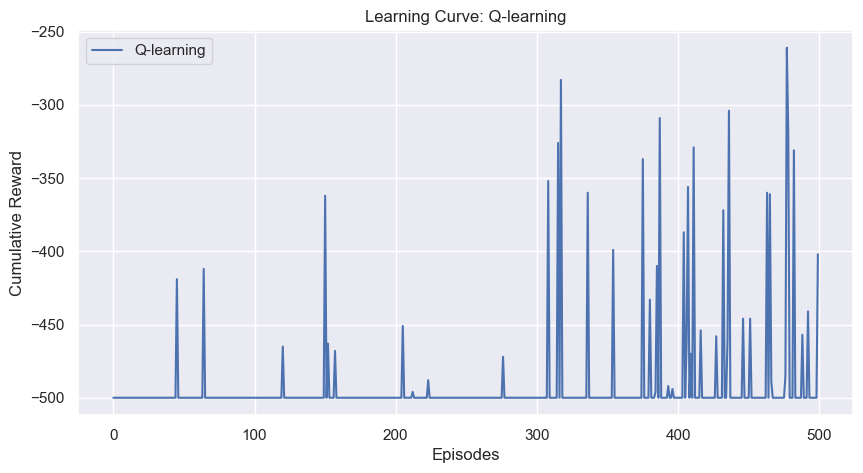

2026-04-10 21:35:13 | INFO    | Plot created in notebook.


100%|█████████▉| 499/500 [00:03<00:00, 160.89it/s]


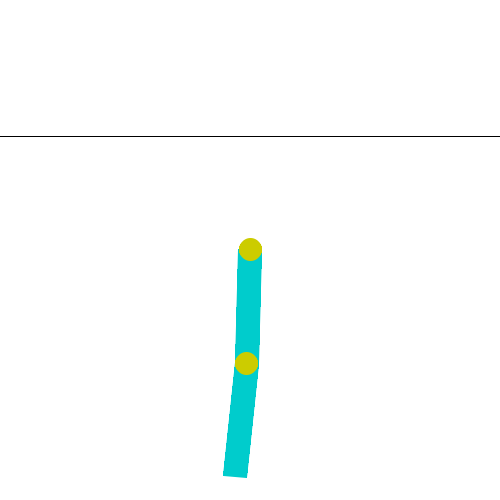

In [14]:
# Initial Run

Q_1, rewards_1 = run_experiment(train_Q, name = "Q-learning")

### Parameter search

In [15]:
main_log.info("Starting Optuna Hyperparameter Search...")
best_trial = param_opt_pipeline(algorithm = train_Q, env = env, n_trials = 64)

best_trial

2026-04-10 21:35:40 | INFO    | Starting Optuna Hyperparameter Search...


Optimizing train_Q: 100%|██████████| 64/64 [4:33:48<00:00, 256.70s/it]  


FrozenTrial(number=21, state=<TrialState.COMPLETE: 1>, values=[-192953.75], datetime_start=datetime.datetime(2026, 4, 10, 23, 53, 58, 322674), datetime_complete=datetime.datetime(2026, 4, 10, 23, 58, 41, 116772), params={'alpha': 0.1148321756702996, 'gamma': 0.9446881785123852, 'epsilon_decay': 0.9162556057561791}, user_attrs={}, system_attrs={}, intermediate_values={0: -192669.0, 1: -192078.5, 2: -191154.0, 3: -190548.75, 4: -190774.0, 5: -191947.83333333334, 6: -191982.7142857143, 7: -192394.75, 8: -192957.22222222222, 9: -193339.9}, distributions={'alpha': FloatDistribution(high=0.3, log=True, low=0.0001, step=None), 'gamma': FloatDistribution(high=0.9999, log=False, low=0.9, step=None), 'epsilon_decay': FloatDistribution(high=0.9999, log=False, low=0.9, step=None)}, trial_id=22, value=None)

In [16]:
best_params = DEFAULT_PARAMS.copy()
best_params.update(best_trial.params)

best_params

{'alpha': 0.1148321756702996,
 'gamma': 0.9446881785123852,
 'epsilon': 1.0,
 'epsilon_decay': 0.9162556057561791,
 'epsilon_min': 0.05,
 'n_episodes': 500}

2026-04-11 02:09:31 | INFO    | Optimization Complete. Best Params found: {'alpha': 0.1148321756702996, 'gamma': 0.9446881785123852, 'epsilon': 1.0, 'epsilon_decay': 0.9162556057561791, 'epsilon_min': 0.05, 'n_episodes': 500}
2026-04-11 02:09:31 | INFO    | Starting Experiment: Opt-Q-learning
2026-04-11 02:09:31 | INFO    | Hyperparameters: {'alpha': 0.1148321756702996, 'gamma': 0.9446881785123852, 'epsilon': 1.0, 'epsilon_decay': 0.9162556057561791, 'epsilon_min': 0.05, 'n_episodes': 500}
2026-04-11 02:10:03 | INFO    | Experiment Opt-Q-learning Finished. Final Avg Reward (last 100 eps): -388.56
2026-04-11 02:10:03 | INFO    | Model checkpoint saved: models/Opt-Q-learning.pkl


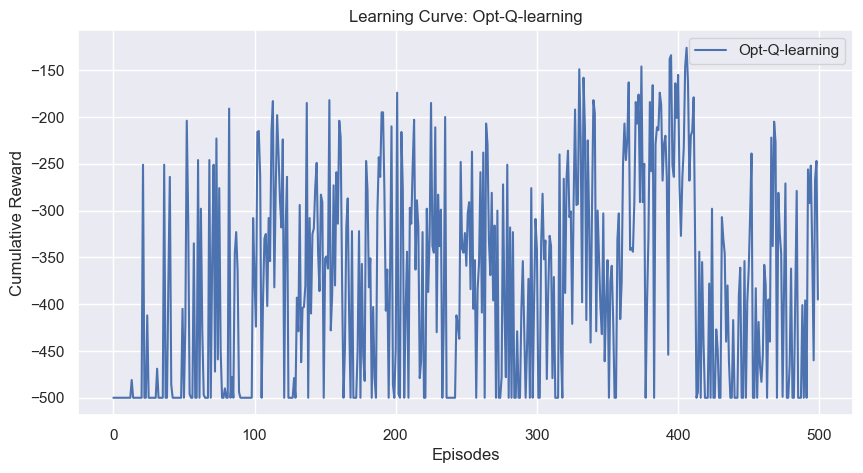

2026-04-11 02:10:03 | INFO    | Plot created in notebook.


 69%|██████▉   | 345/500 [00:01<00:00, 241.29it/s]


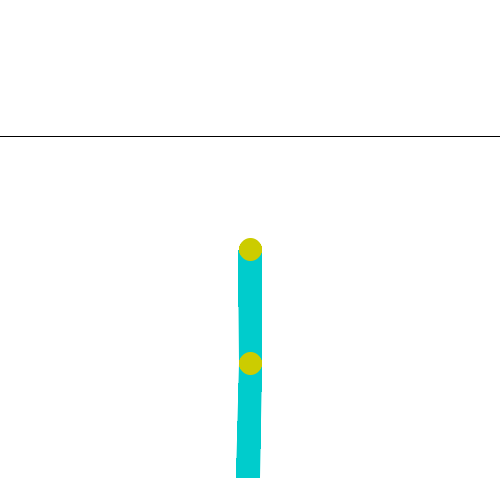

In [17]:
main_log.info(f"Optimization Complete. Best Params found: {best_params}")

Q_1_opt, rewards_1_opt = run_experiment(train_Q, name = "Opt-Q-learning", params = best_params)

## 3. n-step SARSA Experiments [UG: 35 / PGT: 30] marks


In here you will need to implement a version of n-step SARSA, test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of n-step SARSA
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [18]:
def n_step_sarsa(env, params = DEFAULT_PARAMS, n = 5):
    pass

In [19]:
# Initial Run

# Q_2, rewards_2 = run_experiment(n_step_sarsa, name = "n-Step SARSA")

### Parameter search

In [20]:
# main_log.info("Starting Optuna Hyperparameter Search...")
# best_trial = param_opt_pipeline(algorithm = n_step_sarsa, env = env, n_trials = 64)

# best_trial

In [21]:
# best_params = DEFAULT_PARAMS.copy()
# best_params.update(best_trial.params)

# best_params

In [22]:
# main_log.info(f"Optimization Complete. Best Params found: {best_params}")

# Q_2_opt, rewards_2_opt = run_experiment(train_Q, name = "Opt-n-Step-SARSA", params = best_params)

## 4. REINFORCE Experiments [UG: 35 / PGT: 30 ] marks


In here you will need to implement a version of REINFORCE, test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of REINFORCE
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [23]:
def reinforce():
  pass

## 5. SARSA($\lambda$) Experiments [PGT: 20 marks ]


In here you will need to implement a version of SARSA($\lambda$), test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of SARSA($\lambda$)
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [24]:
def sarsa_lambda():
  pass